## Astronomy 3350
### Laboratory 6 - Explore another distribution

October 7 and 9, 2025

#### Instructions:

1. Open a cell below this one, listing all members of your team and today's date.

**Jungyu Baeck**

**7 OCT 25**

2. Use the 'save' operation frequently.
2. Solve each problem in order, save your notebook, then run the whole notebook start-to-finish with the double right arrow button.
3. Upload the notebook to Carmen.

Some problems contain example codes, but others do not.  You will need to copy code cells in several places. You may
add comments to the code, but be sure to provide plenty of commentary and analysis in Markdown cells.

If you do not finish during lab, or if you want to clean things up and write better
documentation afterwards, you may submit your work any time before 9:00 p.m. on
Friday, October 10.

We begin by importing the plot package.  That's all we need.  Do __not__ import anything else.

In [1]:
# Get plots
import matplotlib.pyplot as plt

Now we define a few functions for basic statistics.

In [2]:
# Mean and standard deviation of items in a list
def estimators(values):
    """
    Returns the mean and standard deviation of data in 
    a list.

    Usage:

    mean, sigma = estimators(values)
    """
    # Mean = expectation value
    n   = len(values)
    e_x = sum(values) / n

    # Standard deviation from expectation value formula for variance
    sqr = [a**2 for a in values]
    e1  = sum(sqr) / n
    e2  = sum(values) / n
    var = e1 - e2**2
    sig = var**0.5

    # Return both values
    return e_x, sig

# Read a single column of data
def get_data(filename):
    """
    Reads a single column of data in a formatted file,
    and returns a list.

    Usage: 

    mydata = get_data(filename)

    where 'filename' is a populated string variable
    """
    k = 0
    with open(filename, 'r') as f:
        out = []
        lines = f.readlines()
        for line in lines:
            words = line.split()
            if line[0] == '#' or len(words) == 0:       # Skip comments and blank lines
                ;
            else:
                out.append(float(words[0]))
        k += 1
        return out

### Problem 1

Read the data file using the code provided.  Report the number of data values
in the collection.  Also report the mean and standard deviation of the data
values using the functions defined above.  Alter the code to show __red__ horizontal
lines at the mean $\pm 1\sigma$ where $\sigma$ is the standard deviation.

In [3]:
A = get_data('lab6_data.txt')

In [4]:
# Report mean, number of points here
mean, sigma = estimators(A)
n_values = len(A)

print("Number of data values:", n_values)
print("Mean =", mean)
print("Standard deviation =", sigma)

Number of data values: 512
Mean = 0.5473769531250009
Standard deviation = 0.21864070594691568


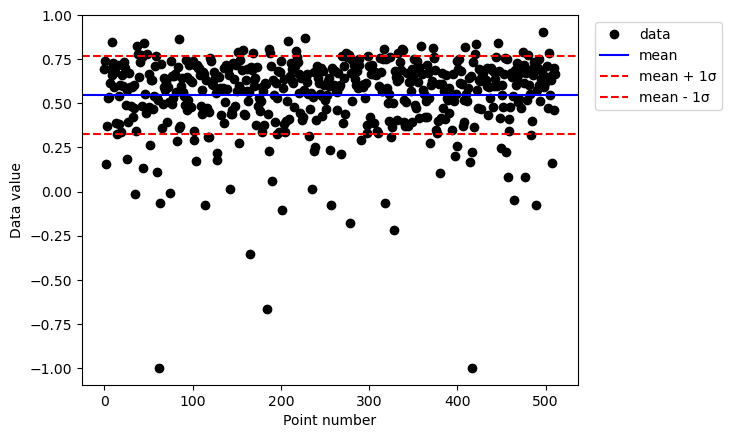

In [5]:
fig, ax = plt.subplots()
ax.plot(A, 'ok', label='data')


ax.axhline(mean, color='blue', label='mean')
ax.axhline(mean + sigma, color='red', linestyle='--', label='mean + 1σ')
ax.axhline(mean - sigma, color='red', linestyle='--', label='mean - 1σ')

# Plot lines for mean and mean plus or minus 3 sigma.
##ml = 0.40          # Replace this with the calculated mean
## ax.axhline(ml, color='blue', label='mean')

# Labels and legend
ax.set_xlabel('Point number')
ax.set_ylabel('Data value')
ax.legend(bbox_to_anchor=(1.02, 1.00), loc="upper left")

# Done
plt.show()

### Problem 2

The normal (or Gaussian) distribution is symmetric around the mean, with a certain 
percentage of points within $\pm 1\sigma$ of the mean.  

- Does this appear to be a symmetric distribution?
- From inspection of the plot, estimate the fraction of points that are outside the mean value $\pm 1\sigma$.
- Calculate the fractions above and below $1\sigma$ explicitly with a list comprehension using code like this:

`high = [x for x in A if x >= mean+sigma]`

`print(len(high) / len(A))`

You will want to use your own variable names in the first line.

- Discuss whether the fractions away from the mean are like what you expect from a normal distibution.

In [6]:
# Calculate fractions above and below ±1σ
high = [x for x in A if x >= mean + sigma]
low  = [x for x in A if x <= mean - sigma]

frac_high = len(high) / len(A)
frac_low  = len(low) / len(A)
frac_outside = frac_high + frac_low

print("Fraction above +1σ:", frac_high)
print("Fraction below -1σ:", frac_low)
print("Total fraction outside ±1σ:", frac_outside)

Fraction above +1σ: 0.064453125
Fraction below -1σ: 0.1015625
Total fraction outside ±1σ: 0.166015625


I expected fraction above and below 1σ would be 0.16 each and total fraction outside ±1σ would be 0.32 statistically.
My data are outside only 0.166, 0.1016 below, 0.0645 above. 
This means my data are roughly symmetric and **more tightly clustered around the mean than a standard Gaussian**


### Problem 3

Now evaluate the cumulative distribution, which is calculated
below.  Using the horizontal and vertical lines,
estimate the median and the interval which contains 2/3 of the points, with equal
numbers above and below that interval.  Compare the median to the mean, and discuss
why one or the other is larger for a distribution like this.

Note that the center of the interval containing 2/3 of the points may not be equal
to the mean or the median.

Median = 0.5974999999999999
Lower bound (1/6): 0.39316666666666666
Upper bound (5/6): 0.7138333333333333
Interval width =  0.32066666666666666


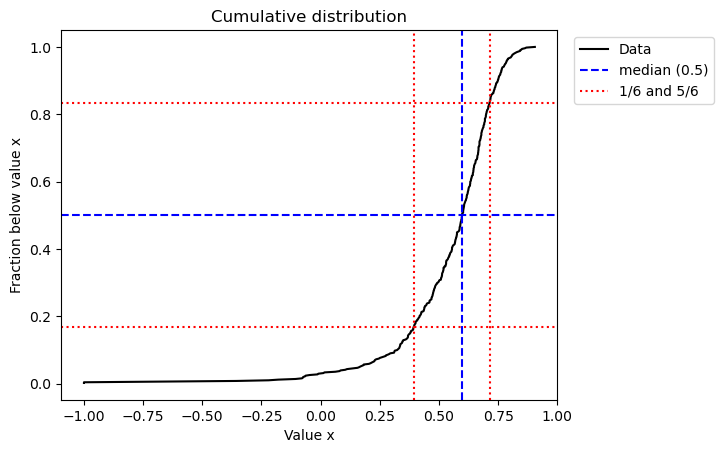

In [7]:
# Generate the cumulative distribution
cA = A.copy()
cA.sort()
f = 1.0 / len(cA)
Y = [ n*f for n in range(1, len(cA)+1) ]

# Calculate median and 2/3 interval

import numpy as np

median = np.percentile(cA, 50)       # 50th percentile
low_bound = np.percentile(cA, 100/6) # ≈ 16.67th percentile
high_bound = np.percentile(cA, 500/6) # ≈ 83.33th percentile

print("Median =", median)
print("Lower bound (1/6):", low_bound)
print("Upper bound (5/6):", high_bound)
print("Interval width = ", high_bound - low_bound)


# Plot the distribution
fig, ax = plt.subplots()
ax.plot(cA, Y, 'black', label='Data')


# Add horizontal and vertical guide lines for median and 2/3 interval
ax.axhline(0.5, color='blue', linestyle='--', label='median (0.5)')
ax.axvline(median, color='blue', linestyle='--')

ax.axhline(1/6, color='red', linestyle=':', label='1/6 and 5/6')
ax.axhline(5/6, color='red', linestyle=':')
ax.axvline(low_bound, color='red', linestyle=':')
ax.axvline(high_bound, color='red', linestyle=':')
      

# Guides
# yline = 0.314            # Set these numbers manually
# xline = 0.71
# ax.axhline(yline, color='red', label='guide')
# ax.axvline(xline, color='red')

# Legend and labels
ax.set_xlabel('Value x')
ax.set_ylabel('Fraction below value x')
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left')
ax.set_title('Cumulative distribution')
plt.show()

### Problem 4

From his long experience in astronomy, your instructor would say:
> This looks like a distribution of the _logarithm_ of some quantity of interest.

So:
- Compute the antilog (i.e., $10^x$ for $x$) of the values in the __A__ list. You should do this with a simple list comprehension.
- Repeat the computation of the cumulative distribution for this new list and plot it.
- Compute statistics for this distriubution, and verify that the fractions above and below $1\sigma$ are what we would expect for some famous statistical distribution. What distribution comes to mind?
- Often we decide that points more than $3\sigma$ away from the mean are erroneous and can be deleted.  Discuss whether this might not be the right thing to do for the original __A__ distribution from what we know about the properties of that distribution.
                                                                                                                             

Number of points = 512
Mean (B) = 3.869515811035442
Std dev (B) = 1.3867211365299943
Fraction above mean+1σ (B): 0.142578125
Fraction below mean-1σ (B): 0.169921875
Total fraction outside ±1σ (B): 0.3125
Median = 3.9582232716178365
Lower bound (1/6): 2.4726737971189894
Upper bound (5/6): 5.174084215041515
Interval width =  2.7014104179225256


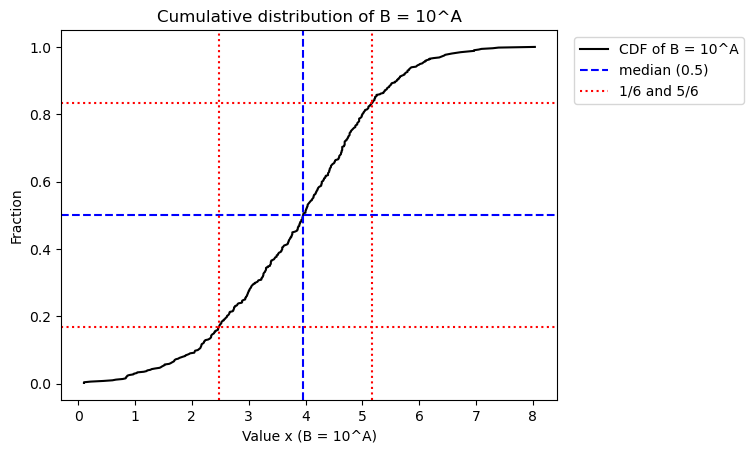

In [8]:
# Compute the antilog (10^x) with a list comprehension
# same computation as above
B = [10.0**x for x in A]

# Compute mean and sigma for B using your estimators()
mean_B, sigma_B = estimators(B)
n_B = len(B)

print("Number of points =", n_B)
print("Mean (B) =", mean_B)
print("Std dev (B) =", sigma_B)

# Fractions above / below mean ± 1σ for B
high_B = [x for x in B if x >= mean_B + sigma_B]
low_B  = [x for x in B if x <= mean_B - sigma_B]
frac_high_B = len(high_B) / n_B
frac_low_B  = len(low_B) / n_B
frac_outside_B = frac_high_B + frac_low_B

print("Fraction above mean+1σ (B):", frac_high_B)
print("Fraction below mean-1σ (B):", frac_low_B)
print("Total fraction outside ±1σ (B):", frac_outside_B)

#cumulative distribution for B (same method as above) ---
cB = B.copy()
cB.sort()
fB = 1.0 / len(cB)
YB = [ n*fB for n in range(1, len(cB)+1) ]

# Plot cumulative distribution of B
fig, ax = plt.subplots()
ax.plot(cB, YB, 'black', label='CDF of B = 10^A')

# Add guides median and 1/6, 5/6 interval for B 
median_B = np.percentile(cB, 50)       # 50th percentile
low_bound_B = np.percentile(cB, 100/6) # ≈ 16.67th percentile
high_bound_B = np.percentile(cB, 500/6) # ≈ 83.33th percentile

print("Median =", median_B)
print("Lower bound (1/6):", low_bound_B)
print("Upper bound (5/6):", high_bound_B)
print("Interval width = ", high_bound_B - low_bound_B)


ax.axhline(0.5, color='blue', linestyle='--', label='median (0.5)')
ax.axvline(median_B, color='blue', linestyle='--')
ax.axhline(1/6, color='red', linestyle=':', label='1/6 and 5/6')
ax.axhline(5/6, color='red', linestyle=':')
ax.axvline(low_bound_B, color='red', linestyle=':')
ax.axvline(high_bound_B, color='red', linestyle=':')

ax.set_xlabel('Value x (B = 10^A)')
ax.set_ylabel('Fraction')
ax.set_title('Cumulative distribution of B = 10^A')
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

Fraction above mean+1σ (B): 0.142578125
Fraction below mean-1σ (B): 0.169921875
Total fraction outside ±1σ (B): 0.3125
These look theoretical Gaussian normal distribution.


Deleting points more than 3σ away from the mean assumes a symmetric Gaussian distribution. If my A values are Gaussian, meaning actually looking at log-values, then clipping at ±3σ in A is a sensible outlier test. But in antilog B (linear), deleting space outside of ±3σ_B is dangerous because distribution of B is skewed an is asymmetric and extreme values can be still meaningful.